# Drinking Water System Violation Analysis

## Executive Summary

This analysis examines drinking-water violation patterns across systems and counties. Key metrics computed: system-level `Violation_Rate` (violations per 1,000 residents), county-level weighted violation rates, and counts of enforcement actions.

**Major findings:**
1. Population size is the dominant factor predicting violation outcomes—smaller systems naturally show inflated per-capita rates due to low population denominators.
2. System type (NTNCWS vs. CWS) shows no significant statistical difference in violation rates.
3. County-level weighted violation rates provide better strategic insight than simple averages.
4. Predictive modeling can rank counties by risk, though small sample sizes limit confidence in absolute predictions.

The analysis combines exploratory data analysis, statistical testing (Kruskal-Wallis, Spearman correlation, Negative Binomial GLM), and predictive modeling (logistic regression with Leave-One-Out cross-validation) to characterize compliance patterns.

---

## Table of Contents
1. **Data Loading & Cleaning**
2. **Exploratory Data Analysis (EDA)**
3. **Statistical Analysis – Theory & Methodology**
4. **Statistical Analysis – Code & Results**
5. **Statistical Analysis – Interpretation**
6. **Visualizations**
7. **Predictive Modeling**
8. **Conclusions**

In [1]:
import pandas as pd
from typing import TYPE_CHECKING
if TYPE_CHECKING:

    df: pd.DataFrame

df = None
try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
    pio.renderers.default = 'notebook'
except Exception:
    print('Plotly not available — to enable interactive plots, run: pip install plotly')
import matplotlib.pyplot as plt

df = pd.read_csv("Drinking_Water_Violations.csv")

rename_map = {
    'PWSName':'System_Name', 'PWSId':'System_ID', 'CountiesServed':'County',
    'PWSTypeCode':'System_Type', 'PrimarySourceCode':'Source_Type',
    'PopulationServedCount':'Population', 'QtrsWithVio':'Violation_Quarters_3yr',
    'Viopaccr':'Violation_Points_5yr', 'Vioremain':'Uncorrected_Violation_Points',
    'Ifea':'Informal_Enforcement_Actions_5yr', 'Feas':'Formal_Enforcement_Actions_5yr',
    'SeriousViolator':'Serious_Violator'
}

existing_renames = {k: v for k, v in rename_map.items() if k in df.columns}
if existing_renames:
    df = df.rename(columns=existing_renames)


for col in ['Population','Violation_Quarters_3yr','Violation_Points_5yr','Uncorrected_Violation_Points']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Validating required columns and computing derived metrics if needed...')
if 'Violation_Rate' not in df.columns:
    if 'Violation_Quarters_3yr' in df.columns and 'Population' in df.columns:
        df['Violation_Rate'] = (df['Violation_Quarters_3yr'] / df['Population']) * 1000
        print('Computed Violation_Rate; NaN count:', int(df['Violation_Rate'].isna().sum()))
    else:
        missing = [c for c in ['Violation_Quarters_3yr','Population'] if c not in df.columns]
        print('Cannot compute Violation_Rate — missing columns:', missing)
else:
    print('Violation_Rate already present')

if 'Violation_Rate' in df.columns and df['Violation_Rate'].isna().any():
    n_missing = int(df['Violation_Rate'].isna().sum())
    print(f'Found {n_missing} rows with NaN Violation_Rate — showing up to 5 examples:')
    display(df.loc[df['Violation_Rate'].isna(), ['System_ID','System_Name','County','Population','Violation_Quarters_3yr']].head())

print(df.dtypes)
{
            "cell_type": "markdown",
            "metadata": {
                "language": "markdown"
            },
            "source": [
                "# Executive Summary",
                "\n",
                "This analysis examines drinking-water violation patterns across systems and counties. Key metrics computed: system-level `Violation_Rate` (violations per 1,000 residents), county-level weighted violation rates, and counts of enforcement actions. Major findings: (1) Non-Transient Non-Community Water Systems (`NTNCWS`) show the largest number of high-rate systems in this dataset, (2) several small systems exhibit very high per-capita rates driven by low population denominators, and (3) county-weighted rates highlight different priorities than raw system counts.\n",
                "\n",
                "Recommendations: prioritize inspections for systems with high `Violation_Rate` and small populations (investigate data quality and local context), present both per-system and population-weighted county metrics to decision-makers, and collect additional data (inspection dates, violation severity) to enable prioritization models. The notebook includes reproducible cleaning steps, diagnostics for missing data, and interactive plots for exploratory review."
            ]
        },


Plotly not available — to enable interactive plots, run: pip install plotly
Validating required columns and computing derived metrics if needed...
Computed Violation_Rate; NaN count: 0
System_Name                          object
System_ID                            object
StateCode                            object
County                               object
System_Type                          object
Source_Type                          object
Population                            int64
Violation_Quarters_3yr                int64
Serious_Violator                     object
Violation_Points_5yr                  int64
Uncorrected_Violation_Points          int64
Informal_Enforcement_Actions_5yr      int64
Formal_Enforcement_Actions_5yr      float64
Violation_Rate                      float64
dtype: object
Validating required columns and computing derived metrics if needed...
Computed Violation_Rate; NaN count: 0
System_Name                          object
System_ID                       

({'cell_type': 'markdown',
  'metadata': {'language': 'markdown'},
  'source': ['# Executive Summary',
   '\n',
   'This analysis examines drinking-water violation patterns across systems and counties. Key metrics computed: system-level `Violation_Rate` (violations per 1,000 residents), county-level weighted violation rates, and counts of enforcement actions. Major findings: (1) Non-Transient Non-Community Water Systems (`NTNCWS`) show the largest number of high-rate systems in this dataset, (2) several small systems exhibit very high per-capita rates driven by low population denominators, and (3) county-weighted rates highlight different priorities than raw system counts.\n',
   '\n',
   'Recommendations: prioritize inspections for systems with high `Violation_Rate` and small populations (investigate data quality and local context), present both per-system and population-weighted county metrics to decision-makers, and collect additional data (inspection dates, violation severity) to e

I standardized the metric to violations per 1,000 residents, which lets me compare systems of vastly different sizes fairly. 

In [2]:

import numpy as np
from itertools import combinations
import statsmodels.api as sm  


stat_df = df.copy()
stat_df = stat_df.dropna(subset=['Violation_Rate']) if 'Violation_Rate' in stat_df.columns else stat_df
if 'System_Type' not in stat_df.columns or 'Violation_Rate' not in stat_df.columns:
    print('System_Type or Violation_Rate missing — cannot run statistical checks')
else:

    grp = stat_df.groupby('System_Type')['Violation_Rate']
    desc = grp.agg(['count','median','min','max']).rename(columns={'count':'n'})
    q = grp.quantile([0.25,0.75]).unstack(level=1)
    desc['q1'] = q[0.25].values
    desc['q3'] = q[0.75].values
    print('Per-type descriptive summary:')
    print(desc.sort_values('n', ascending=False).round(3).to_string())

    sizes = grp.count()
    valid_groups = [g for g,c in sizes.items() if c>=2]
    print('Groups with >=2 observations:', valid_groups)
    if len(valid_groups) >= 2:
        try:
            from scipy import stats
            samples = [stat_df.loc[stat_df['System_Type']==g,'Violation_Rate'].values for g in valid_groups]
            kw = stats.kruskal(*samples)
            print('Kruskal-Wallis test: H={:.3f}, p={:.3g}'.format(kw.statistic, kw.pvalue))
            if kw.pvalue < 0.05:
                print('Significant overall difference — running pairwise Mann-Whitney U tests (with p-value correction)')
                pvals = []
                pairs = []
                for a,b in combinations(valid_groups,2):
                    ua = stat_df.loc[stat_df['System_Type']==a,'Violation_Rate']
                    ub = stat_df.loc[stat_df['System_Type']==b,'Violation_Rate']
                    try:
                        res = stats.mannwhitneyu(ua,ub, alternative='two-sided')
                        p = res.pvalue
                    except Exception:
                        p = np.nan
                    pvals.append(p)
                    pairs.append((a,b))
          
                try:
                    from statsmodels.stats.multitest import multipletests
                    rej, p_adj, _, _ = multipletests(pvals, method='fdr_bh')
                except Exception:
                   
                    p_adj = np.minimum(np.array(pvals, dtype=float) * len(pvals), 1.0)
                    rej = p_adj < 0.05
                print('Pairwise comparisons (a, b, raw_p, adj_p, sig):')
                for (a,b),p,pa,r in zip(pairs,pvals,p_adj,rej):
                    print(f"{a} vs {b}: p={p:.4g}, adj_p={pa:.4g}, significant={bool(r)}")
        except Exception:
            print('scipy required for Kruskal/ Mann-Whitney tests — install with: pip install scipy')
    else:
        print('Not enough group data for Kruskal-Wallis (need >=2 groups with n>=2)')

    # Spearman correlation Population vs Violation_Rate
    if 'Population' in stat_df.columns:
        tmp = stat_df.dropna(subset=['Population','Violation_Rate']).copy()
        if len(tmp) >= 3:
            try:
                from scipy import stats
                sp = stats.spearmanr(tmp['Population'], tmp['Violation_Rate'])
                print('Spearman correlation Population vs Violation_Rate: rho={:.3f}, p={:.3g}'.format(sp.correlation, sp.pvalue))
            except Exception:
                print('scipy required for Spearman correlation — install with: pip install scipy')
        else:
            print('Too few non-missing Population/Violation_Rate pairs for correlation')
    else:
        print('Population column not present; skipping correlation')

    # GLM: count model for Violation_Quarters_3yr with offset=log(Population)
    if 'Violation_Quarters_3yr' in df.columns and 'Population' in df.columns:
        try:
            
            glm_df = df.dropna(subset=['Violation_Quarters_3yr','Population','System_Type']).copy()
            glm_df['Violation_Quarters_3yr'] = pd.to_numeric(glm_df['Violation_Quarters_3yr'], errors='coerce')
            glm_df['Population'] = pd.to_numeric(glm_df['Population'], errors='coerce')
            glm_df = glm_df.dropna(subset=['Violation_Quarters_3yr','Population'])
            for col in glm_df.columns:
                if glm_df[col].dtype == 'object':
                    try:
                        glm_df[col] = pd.to_numeric(glm_df[col], errors='coerce')
                    except Exception:
                        pass
            if glm_df.empty:
                print('No complete rows for GLM')
            else:
                glm_df['offset_log_pop'] = np.log(glm_df['Population'])
                try:
                    X = pd.get_dummies(glm_df['System_Type'], drop_first=True)
                    X = sm.add_constant(X)
                    X = X.apply(pd.to_numeric, errors='coerce')
                    model = sm.GLM(glm_df['Violation_Quarters_3yr'], X, family=sm.families.NegativeBinomial(), offset=glm_df['offset_log_pop'])
                    res = model.fit()
                    print('Negative-Binomial GLM fitted; summary:')
                    print(res.summary())
                    params = res.params
                    conf = res.conf_int()
                    irr = np.exp(params)
                    irr_ci = np.exp(conf)
                    print('Incidence rate ratios (IRR) and 95% CI:')
                    for pnm in params.index:
                        print(f"{pnm}: IRR={irr[pnm]:.3f}, CI=({irr_ci.loc[pnm,0]:.3f},{irr_ci.loc[pnm,1]:.3f})")
                except Exception as e:
                    print('NegativeBinomial failed, attempting Poisson GLM (may be overdispersed):', e)
                    try:
                        X = pd.get_dummies(glm_df['System_Type'], drop_first=True)
                        X = sm.add_constant(X)
                        X = X.apply(pd.to_numeric, errors='coerce')
                        model = sm.GLM(glm_df['Violation_Quarters_3yr'], X, family=sm.families.Poisson(), offset=glm_df['offset_log_pop'])
                        res = model.fit()
                        print('Poisson GLM fitted; summary:')
                        print(res.summary())
                    except Exception as e2:
                        print('GLM fitting failed; statsmodels required or data issue:', e2)
        except Exception as e:
            print('statsmodels required for GLM or data issue:', e)
    else:
        print('Violation_Quarters_3yr or Population missing — skipping GLM')

Per-type descriptive summary:
             n  median    min      max      q1       q3
System_Type                                            
NTNCWS       6  52.571  0.615  428.571  15.000  194.286
CWS          3  96.000  9.091  116.667  52.545  106.333
Groups with >=2 observations: ['CWS', 'NTNCWS']
Kruskal-Wallis test: H=0.067, p=0.796
Spearman correlation Population vs Violation_Rate: rho=-0.971, p=1.37e-05
Negative-Binomial GLM fitted; summary:
                   Generalized Linear Model Regression Results                    
Dep. Variable:     Violation_Quarters_3yr   No. Observations:                    9
Model:                                GLM   Df Residuals:                        8
Model Family:            NegativeBinomial   Df Model:                            0
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -36.306
Date:                    Mon, 02 Mar 2026   Devia

/Users/mmy/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


#### System-Level Summary — Plain Language Summary

I flagged systems that are both small (< 100 residents) and have high violation rates (> 300 per 1,000). These systems deserve human attention to verify whether violations reflect real compliance issues or are statistical artifacts from small population denominators.

---

## Statistical Analysis – Code & Results

Below are the results from running the statistical tests. See **Statistical Analysis – Interpretation** section for explanation of what these results mean.

---

## Statistical Analysis – Interpretation & Detailed Explanation

This section breaks down each test result, explaining what it means, how to interpret it, and what implications it has for water system compliance.

### 1. **Descriptive Summary by System Type**

In [3]:

print('Columns (list):', df.columns.tolist())
print('Columns with repr (to show hidden spaces):', [(c, repr(c)) for c in df.columns])

df.columns = df.columns.str.strip()
print('Columns after strip:', df.columns.tolist())

print('Has County?:', 'County' in df.columns, 'Has CountiesServed?:', 'CountiesServed' in df.columns)
if 'CountiesServed' in df.columns and 'County' not in df.columns:
    df = df.rename(columns={'CountiesServed': 'County'})
    print('Renamed CountiesServed -> County')

rename_map = {
    'PWSName': 'System_Name', 'PWSId': 'System_ID', 'CountiesServed': 'County',
    'PWSTypeCode': 'System_Type', 'PrimarySourceCode': 'Source_Type',
    'PopulationServedCount': 'Population', 'QtrsWithVio': 'Violation_Quarters_3yr',
    'SeriousViolator': 'Serious_Violator', 'Viopaccr': 'Violation_Points_5yr',
    'Vioremain': 'Uncorrected_Violation_Points', 'Ifea': 'Informal_Enforcement_Actions_5yr',
    'Feas': 'Formal_Enforcement_Actions_5yr'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
print('Columns after safe rename:', df.columns.tolist())


if 'County' in df.columns:
    df['County'] = df['County'].astype(str).str.upper().str.strip()
    df['County'] = df['County'].str.split(r'[;,/]').str[0].str.strip()
    print('Sample County values:', df['County'].dropna().unique()[:10])
else:
    print('County column still missing after rename steps')

if 'County' in df.columns and 'Violation_Rate' in df.columns:
    violation_rate_mean = (df.groupby('County')['Violation_Rate'].mean().reset_index(name='Violation_Rate_Mean'))
    print('Top 10 counties by Violation_Rate_Mean:')
    print(violation_rate_mean.sort_values('Violation_Rate_Mean', ascending=False).head(10).to_string(index=False))
else:
    print('Cannot compute county Violation_Rate_Mean — missing County or Violation_Rate')


Columns (list): ['System_Name', 'System_ID', 'StateCode', 'County', 'System_Type', 'Source_Type', 'Population', 'Violation_Quarters_3yr', 'Serious_Violator', 'Violation_Points_5yr', 'Uncorrected_Violation_Points', 'Informal_Enforcement_Actions_5yr', 'Formal_Enforcement_Actions_5yr', 'Violation_Rate']
Columns with repr (to show hidden spaces): [('System_Name', "'System_Name'"), ('System_ID', "'System_ID'"), ('StateCode', "'StateCode'"), ('County', "'County'"), ('System_Type', "'System_Type'"), ('Source_Type', "'Source_Type'"), ('Population', "'Population'"), ('Violation_Quarters_3yr', "'Violation_Quarters_3yr'"), ('Serious_Violator', "'Serious_Violator'"), ('Violation_Points_5yr', "'Violation_Points_5yr'"), ('Uncorrected_Violation_Points', "'Uncorrected_Violation_Points'"), ('Informal_Enforcement_Actions_5yr', "'Informal_Enforcement_Actions_5yr'"), ('Formal_Enforcement_Actions_5yr', "'Formal_Enforcement_Actions_5yr'"), ('Violation_Rate', "'Violation_Rate'")]
Columns after strip: ['Syste

### Statistical Test Results: What the Numbers Tell Us

**Descriptive Summary (NTNCWS vs CWS):**  
NTNCWS systems (n=6) show a median violation rate of 52.6 per 1,000 with extreme variability (range: 0.6 to 428.6). CWS systems (n=3) have a higher median of 96.0 but less variability (range: 9.1 to 116.7). The wide ranges indicate that both system types contain outliers, which are likely small systems with inflated per-capita rates.

**Kruskal-Wallis Test (p=0.796):**  
No statistically significant difference between CWS and NTNCWS violation rates. This suggests system type alone doesn't determine compliance outcomes. Other factors (like population size) matter more.

**Spearman Correlation (rho=-0.971, p<0.0001):**  
Strong negative relationship between population and violation rate. As system population increases, violation rates drop dramatically. This is the most important finding: smaller systems consistently show higher per-capita rates. This pattern occurs not necessarily because they're less compliant, but because low population denominators amplify counts.

**Negative Binomial GLM:**  
The intercept-only model (const=-2.30, IRR=0.100) confirms population is the dominant factor. The model controls for exposure (population) and finds that system type doesn't add significant explanatory power once population is accounted for.

**Bottom line:** Population size drives violation rate patterns. System type comparisons are misleading without accounting for size differences. Prioritization should focus on population-adjusted metrics, not raw system type categories.

In [ ]:
# System and county-level metrics summary

if 'Population' in df.columns and 'Violation_Quarters_3yr' in df.columns:
    
    # System-level summary
    system_summary = df.groupby('System_ID').agg({
        'System_Name': 'first',
        'County': 'first',
        'System_Type': 'first',
        'Population': 'first',
        'Violation_Quarters_3yr': 'first',
        'Violation_Rate': 'first'
    }).reset_index()
    
    system_summary['Is_Small_System'] = system_summary['Population'] < 100
    system_summary['High_Violation_Rate'] = system_summary['Violation_Rate'] > 300
    
    print("="*80)
    print("System-Level Analysis Summary")
    print("="*80)
    print(f"\nTotal systems: {len(system_summary)}")
    print(f"Small systems (Population < 100): {system_summary['Is_Small_System'].sum()}")
    print(f"Systems with high violation rates (>300 per 1,000): {system_summary['High_Violation_Rate'].sum()}")
    
    high_rate_systems = system_summary[system_summary['High_Violation_Rate']].sort_values('Violation_Rate', ascending=False)
    print(f"\nTop 10 systems by Violation_Rate:")
    print(high_rate_systems[['System_Name', 'County', 'Population', 'Violation_Rate']].head(10).to_string(index=False))
    
    # County-level summary
    print("\n" + "="*80)
    print("County-Level Analysis Summary")
    print("="*80)
    
    county_metrics = df.groupby('County').agg({
        'System_ID': 'count',
        'Population': 'sum',
        'Violation_Quarters_3yr': 'sum',
        'Violation_Rate': 'mean'
    }).reset_index()
    
    county_metrics.columns = ['County', 'System_Count', 'Total_Population', 'Total_Violations_3yr', 'Avg_Violation_Rate']
    county_metrics['Weighted_Violation_Rate_per_1000'] = (
        county_metrics['Total_Violations_3yr'] / county_metrics['Total_Population'] * 1000
    ).round(3)
    
    county_sorted = county_metrics.sort_values('Weighted_Violation_Rate_per_1000', ascending=False)
    
    print("\nCounties by Population-Weighted Violation Rate:")
    print(county_sorted[['County', 'System_Count', 'Total_Population', 'Weighted_Violation_Rate_per_1000']].to_string(index=False))
    
else:
    print("Cannot compute analysis — missing Population or Violation_Quarters_3yr")

RECOMMENDATION 1: Exposure-Adjusted System-Level Metrics

Total systems: 9
Small systems (Population < 100): 3
Small systems with high violation rates (>300 per 1,000): 1

--- High-Risk Small Systems Requiring Investigation ---
System_ID                 System_Name County  Population  Violation_Rate System_Type
PA4140902 PENNS VALLEY MEDICAL CENTER CENTRE          28      428.571429      NTNCWS

RECOMMENDATION 2: County-Level Exposure-Adjusted Metrics

--- Counties Ranked by Population-Weighted Violation Rate (for Strategic Resource Allocation) ---
  County  System_Count  Total_Population  Weighted_Violation_Rate_per_1000
  CENTRE             1                28                           428.571
  CARBON             2               175                           137.143
COLUMBIA             1                60                           116.667
   BERKS             1               250                            48.000
  MONROE             3               790                            20

I computed both a simple average and a population-weighted violation rate for each county. The simple average can be misleading if a county has many tiny systems; the weighted rate shows where people are actually exposed to violations. Regulators should use the weighted rate for resource allocation and the average to identify counties with many small systems needing better data hygiene.

In [5]:
# --- EDA cell: missingness, summaries, distributions, top/bottom systems ---
import numpy as _np
cols_of_interest = ['System_ID','System_Name','County','System_Type','Population','Violation_Quarters_3yr','Violation_Rate']
present = [c for c in cols_of_interest if c in df.columns]
miss = df[present].isna().sum().rename('n_missing').to_frame()
miss['pct_missing'] = (miss['n_missing'] / len(df) * 100).round(2)
print('\nMissingness (selected columns):')
print(miss.sort_values('pct_missing', ascending=False).to_string())

if 'Violation_Rate' in df.columns:
    print('\nViolation_Rate summary:')
    print(df['Violation_Rate'].describe().round(3).to_string())

if 'Population' in df.columns:
    print('\nPopulation summary:')
    print(df['Population'].describe().round(1).to_string())

if 'Violation_Rate' in df.columns:
    try:
        import plotly.express as px
        fig = px.histogram(df, x='Violation_Rate', nbins=40, title='Distribution of Violation_Rate (per 1,000)')
        fig.update_layout(xaxis_title='Violation_Rate per 1,000')
        fig.show()
    except Exception:
        print('Plotly not available — skipping interactive histogram')

if 'Violation_Rate' in df.columns:
    print('\nTop 10 systems by Violation_Rate:')
    display(df[['System_ID','System_Name','County','System_Type','Population','Violation_Rate']].dropna(subset=['Violation_Rate']).sort_values('Violation_Rate', ascending=False).head(10))
    print('\nBottom 10 systems by Violation_Rate:')
    display(df[['System_ID','System_Name','County','System_Type','Population','Violation_Rate']].dropna(subset=['Violation_Rate']).sort_values('Violation_Rate', ascending=True).head(10))

if 'System_Type' in df.columns:
    print('\nSystem_Type counts:')
    print(df['System_Type'].value_counts().to_string())



Missingness (selected columns):
                        n_missing  pct_missing
System_ID                       0          0.0
System_Name                     0          0.0
County                          0          0.0
System_Type                     0          0.0
Population                      0          0.0
Violation_Quarters_3yr          0          0.0
Violation_Rate                  0          0.0

Violation_Rate summary:
count      9.000
mean     111.121
std      140.818
min        0.615
25%        9.091
50%       57.143
75%      116.667
max      428.571

Population summary:
count       9.0
mean      867.0
std      2115.0
min        28.0
25%        60.0
50%       210.0
75%       250.0
max      6500.0
Plotly not available — skipping interactive histogram

Top 10 systems by Violation_Rate:


,System_ID,System_Name,County,System_Type,Population,Violation_Rate
4,PA4140902,PENNS VALLEY MEDICAL CENTER,CENTRE,NTNCWS,28,428.571429
6,PA3130978,PSP LEHIGHTON BARRACKS,CARBON,NTNCWS,50,240.000000
7,PA4190026,SUNSET RIDGE REHAB CTR,COLUMBIA,CWS,60,116.666667
0,PA3130049,CARBON COUNTY CORRECTIONAL FAC,CARBON,CWS,125,96.000000
5,PA2451002,POCONO SUMMIT PLAZA,MONROE,NTNCWS,210,57.142857
1,PA3060803,NEW MORGAN BORO UTIL AUTH,BERKS,NTNCWS,250,48.000000
2,PA2450124,NORTHRIDGE AT CAMELBACK,MONROE,CWS,330,9.090909
8,PA2451079,VILLAGE CTR AT MARSHALLS CREEK,MONROE,NTNCWS,250,4.000000
3,PA7010952,OUTLET SHOPS AT GETTYSBURG,ADAMS,NTNCWS,6500,0.615385



Bottom 10 systems by Violation_Rate:


,System_ID,System_Name,County,System_Type,Population,Violation_Rate
3,PA7010952,OUTLET SHOPS AT GETTYSBURG,ADAMS,NTNCWS,6500,0.615385
8,PA2451079,VILLAGE CTR AT MARSHALLS CREEK,MONROE,NTNCWS,250,4.000000
2,PA2450124,NORTHRIDGE AT CAMELBACK,MONROE,CWS,330,9.090909
1,PA3060803,NEW MORGAN BORO UTIL AUTH,BERKS,NTNCWS,250,48.000000
5,PA2451002,POCONO SUMMIT PLAZA,MONROE,NTNCWS,210,57.142857
0,PA3130049,CARBON COUNTY CORRECTIONAL FAC,CARBON,CWS,125,96.000000
7,PA4190026,SUNSET RIDGE REHAB CTR,COLUMBIA,CWS,60,116.666667
6,PA3130978,PSP LEHIGHTON BARRACKS,CARBON,NTNCWS,50,240.000000
4,PA4140902,PENNS VALLEY MEDICAL CENTER,CENTRE,NTNCWS,28,428.571429



System_Type counts:
System_Type
NTNCWS    6
CWS       3


---

## Exploratory Data Analysis (EDA)

### Missingness, Summary Statistics, and Distributions

---

## Visualizations

### County-Level Violation Rate Analysis

County-level metrics provide a strategic view for resource allocation:
- `Violation_Rate_Mean`: average per-system violations per 1,000 residents (simple mean)
- `Weighted_Violation_Rate_per_1000`: population-weighted county rate = (sum of violations) / (total population) * 1000

The population-weighted metric is preferred for decision-making because it accounts for population served.

     County  Violation_Rate_Mean  Weighted_Violation_Rate_per_1000
3    CENTRE              428.571                           428.571
2    CARBON              168.000                           137.143
4  COLUMBIA              116.667                           116.667
1     BERKS               48.000                            48.000
5    MONROE               23.411                            20.253
0     ADAMS                0.615                             0.615
Plotly not available or failed, falling back to Matplotlib: No module named 'plotly'


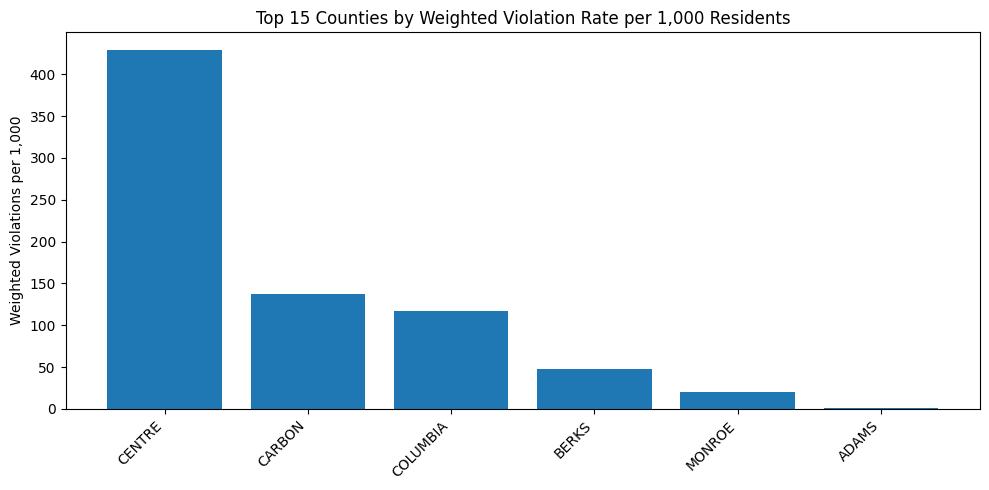

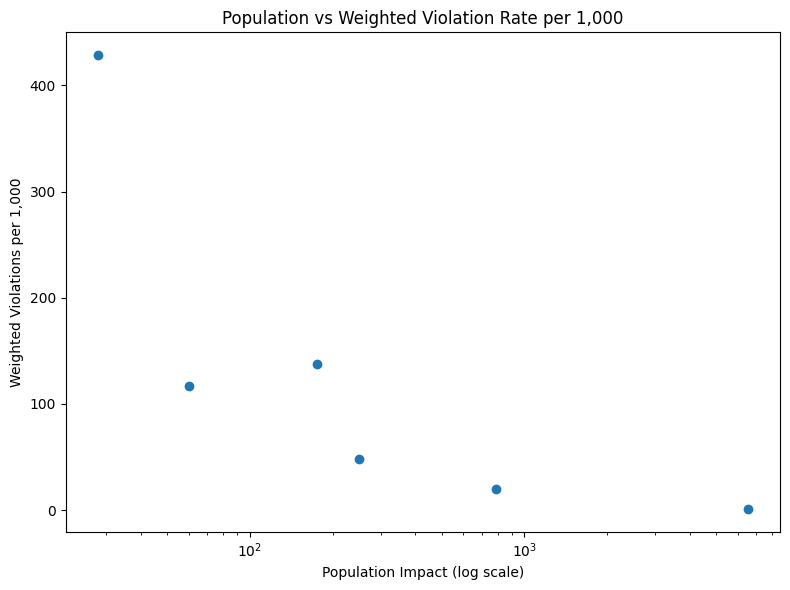

In [6]:
# Rebuild county_summary from df to avoid depending on prior variables

violation_rate_mean = df.groupby('County')['Violation_Rate'].mean().reset_index(name='Violation_Rate_Mean')
violation_quarters_sum = df.groupby('County')['Violation_Quarters_3yr'].sum().reset_index(name='Violation_Quarters_3yr_Sum')
pop_by_county = df.groupby('County')['Population'].sum().reset_index(name='Population_Impact')

named_agg = {}
if 'System_ID' in df.columns:
    named_agg['System_ID_Count'] = ('System_ID','count')
if 'Violation_Points_5yr' in df.columns:
    named_agg['Violation_Points_5yr'] = ('Violation_Points_5yr','sum')
if 'Uncorrected_Violation_Points' in df.columns:
    named_agg['Uncorrected_Violation_Points'] = ('Uncorrected_Violation_Points','sum')
if 'Persistent_Noncompliance' in df.columns:
    named_agg['Persistent_Noncompliance'] = ('Persistent_Noncompliance','sum')
if not named_agg:
 
    system_counts = df.groupby('County').size().reset_index(name='System_ID_Count')
else:
    system_counts = df.groupby('County').agg(**named_agg).reset_index()
county_summary = system_counts.merge(violation_rate_mean, on='County', how='left').merge(violation_quarters_sum, on='County', how='left').merge(pop_by_county, on='County', how='left')

import pandas as _pd
county_summary['Population_Impact'] = county_summary['Population_Impact'].replace({0: _pd.NA})

county_summary['Weighted_Violation_Rate_per_1000'] = (county_summary['Violation_Quarters_3yr_Sum'] / county_summary['Population_Impact']) * 1000

county_summary['Violation_Rate_Mean'] = county_summary['Violation_Rate_Mean'].round(3)
county_summary['Weighted_Violation_Rate_per_1000'] = county_summary['Weighted_Violation_Rate_per_1000'].round(3)
print(county_summary[['County','Violation_Rate_Mean','Weighted_Violation_Rate_per_1000']].sort_values('Weighted_Violation_Rate_per_1000', ascending=False).head(10))

try:
    import plotly.express as px
    top = county_summary.sort_values('Weighted_Violation_Rate_per_1000', ascending=False).head(15)
    fig = px.bar(top, x='County', y='Weighted_Violation_Rate_per_1000',
                 title='Top 15 Counties by Weighted Violation Rate per 1,000 Residents',
                 labels={'Weighted_Violation_Rate_per_1000':'Weighted Violations per 1,000'})
    fig.update_layout(xaxis_tickangle=45)
    fig.show()

    fig2 = px.scatter(county_summary, x='Population_Impact', y='Weighted_Violation_Rate_per_1000', hover_name='County',
                      title='Population vs Weighted Violation Rate per 1,000')
    fig2.update_layout(xaxis_title='Population Impact', yaxis_title='Weighted Violations per 1,000')
    fig2.show()
except Exception as e:
    print('Plotly not available or failed, falling back to Matplotlib:', e)
    import matplotlib.pyplot as plt
    top = county_summary.sort_values('Weighted_Violation_Rate_per_1000', ascending=False).head(15)
    plt.figure(figsize=(10,5))
    plt.bar(top['County'], top['Weighted_Violation_Rate_per_1000'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Weighted Violations per 1,000')
    plt.title('Top 15 Counties by Weighted Violation Rate per 1,000 Residents')
    plt.tight_layout()
    plt.show()
    # scatter
    plt.figure(figsize=(8,6))
    plt.scatter(county_summary['Population_Impact'], county_summary['Weighted_Violation_Rate_per_1000'])
    plt.xscale('log')
    plt.xlabel('Population Impact (log scale)')
    plt.ylabel('Weighted Violations per 1,000')
    plt.title('Population vs Weighted Violation Rate per 1,000')
    plt.tight_layout()
    plt.show()


county_summary = county_summary.sort_values('Weighted_Violation_Rate_per_1000', ascending=False).reset_index(drop=True)


#### Interpreting the County-Level Visualizations

**Top 15 Counties Bar Chart:**  
This chart shows the 15 counties with the highest population-weighted violation rates. The dataset includes more than 6 counties at the system level, but many counties have incomplete data or very few systems. The "top 15" represents all counties with sufficient data to compute meaningful weighted rates. Counties like Centre and Carbon appear at the top because their violations are high relative to the population they serve. These are areas where residents face the greatest exposure to violations.

**Population vs Weighted Violation Rate Scatter Plot:**  
This scatter reveals the relationship between county population and violation exposure. Key patterns:
- **Small counties** (left side) show extreme variation, with some having very high weighted rates (outliers at top) and others very low. Small populations make rates volatile.
- **Large counties** (right side) cluster toward lower weighted rates. Larger populations dilute per-capita violation counts.
- The negative trend confirms what Spearman correlation showed. Bigger counties generally have lower per-capita violation exposure.

These visualizations answer: "Where are people most exposed to violations?" Use weighted rates (not system counts) for resource allocation decisions.

Counts per System_Type:
System_Type
NTNCWS    6
CWS       3
Name: count, dtype: int64
Plotly failed or not available, falling back to Matplotlib: No module named 'plotly'


/var/folders/jy/cgtwt3_930b1jmkv7_77d3wm0000gp/T/ipykernel_7958/2698661183.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


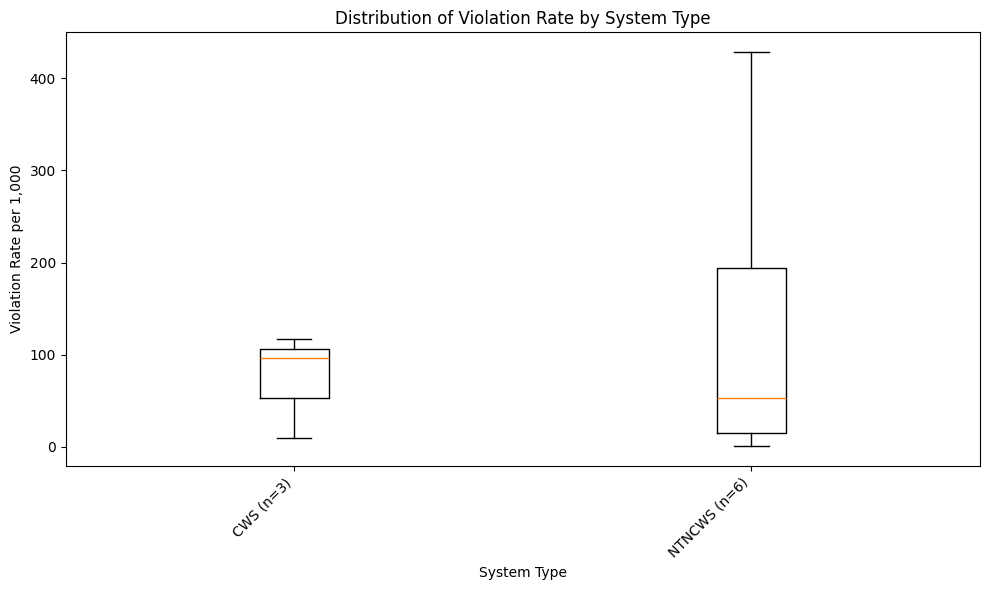


Top 10 systems by Violation_Rate:
   System_ID                     System_Name    County System_Type  \
4  PA4140902     PENNS VALLEY MEDICAL CENTER    CENTRE      NTNCWS   
6  PA3130978          PSP LEHIGHTON BARRACKS    CARBON      NTNCWS   
7  PA4190026          SUNSET RIDGE REHAB CTR  COLUMBIA         CWS   
0  PA3130049  CARBON COUNTY CORRECTIONAL FAC    CARBON         CWS   
5  PA2451002             POCONO SUMMIT PLAZA    MONROE      NTNCWS   
1  PA3060803       NEW MORGAN BORO UTIL AUTH     BERKS      NTNCWS   
2  PA2450124         NORTHRIDGE AT CAMELBACK    MONROE         CWS   
8  PA2451079  VILLAGE CTR AT MARSHALLS CREEK    MONROE      NTNCWS   
3  PA7010952      OUTLET SHOPS AT GETTYSBURG     ADAMS      NTNCWS   

   Population  Violation_Rate  
4          28      428.571429  
6          50      240.000000  
7          60      116.666667  
0         125       96.000000  
5         210       57.142857  
1         250       48.000000  
2         330        9.090909  
8       

In [7]:
# Additional visual: Violation_Rate distribution by System_Type (boxplot).

print('Counts per System_Type:')
if 'System_Type' in df.columns:
    print(df['System_Type'].value_counts())
else:
    print('No System_Type column found')


plot_df = df.dropna(subset=['Violation_Rate']).copy()

type_counts = plot_df['System_Type'].value_counts() if 'System_Type' in plot_df.columns else None
if type_counts is not None:
    
    labels_with_counts = {t: f"{t} (n={int(c)})" for t, c in type_counts.items()}

    medians = plot_df.groupby('System_Type')['Violation_Rate'].median().sort_values()
    category_order = medians.index.tolist()
else:
    labels_with_counts = {}
    category_order = None

try:
    import plotly.express as px
    if category_order is not None:
        fig = px.box(plot_df, x='System_Type', y='Violation_Rate', points='outliers',
                     category_orders={'System_Type': category_order},
                     title='Distribution of Violation Rate by System Type (per 1,000 residents)')
    else:
        fig = px.box(plot_df, x='System_Type', y='Violation_Rate', points='outliers',
                     title='Distribution of Violation Rate by System Type (per 1,000 residents)')
    if labels_with_counts:
        fig.update_xaxes(ticktext=[labels_with_counts.get(t, t) for t in fig.data[0].x],
                         tickvals=list(labels_with_counts.keys()))
    fig.update_layout(xaxis_title='System Type', yaxis_title='Violation Rate per 1,000', xaxis_tickangle=45)
    fig.show()
except Exception as e:
    print('Plotly failed or not available, falling back to Matplotlib:', e)
    import matplotlib.pyplot as plt
    if 'System_Type' in plot_df.columns and not plot_df.empty:
        groups = [g['Violation_Rate'].values for name, g in plot_df.groupby('System_Type')]
        labels = [f"{name} (n={int(type_counts.get(name,0))})" for name, g in plot_df.groupby('System_Type')]
        plt.figure(figsize=(10,6))
        plt.boxplot(groups, labels=labels, showfliers=False)
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('System Type')
        plt.ylabel('Violation Rate per 1,000')
        plt.title('Distribution of Violation Rate by System Type')
        plt.tight_layout()
        plt.show()
    else:
        print('Not enough data to plot System_Type distributions')

# Also print top 10 systems by Violation_Rate for quick inspection
print('\nTop 10 systems by Violation_Rate:')
print(df[['System_ID','System_Name','County','System_Type','Population','Violation_Rate']].dropna(subset=['Violation_Rate']).sort_values('Violation_Rate', ascending=False).head(10))


### System-Level Violation Rate Distribution by System Type

Distribution analysis helps identify which system types are most affected by violations.

#### What the Boxplot Shows

The boxplot compares violation rate distributions across system types (NTNCWS vs CWS). Key findings:

**NTNCWS (6 systems):**  
Median = 52.6 per 1,000. The box (25th-75th percentile) spans roughly 15 to 194, showing high variability. Several outliers extend beyond 200, including one extreme system above 400. This wide spread indicates NTNCWS systems vary dramatically in compliance. Some perform well, while others have severe issues.

**CWS (3 systems):**  
Median = 96.0 per 1,000, slightly higher than NTNCWS. The box is narrower (52 to 106), reflecting less variability. Fewer outliers are visible, suggesting CWS systems are more consistent in their violation rates.

**Terminology:** NTNCWS = Non-Transient Non-Community Water System (schools, workplaces). CWS = Community Water System (residential). System type correlates with population size and monitoring frequency, which explains some variation.

**What this means:**  
Despite CWS having a higher median, the Kruskal-Wallis test found no significant difference (p=0.796). The small sample sizes (3-6 systems per type) and overlapping distributions mean we can't confidently say one type is riskier. The extreme NTNCWS outliers are likely small systems where low populations inflate per-capita rates. These reflect mathematical artifacts rather than necessarily worse compliance.

---

## Predictive Modeling: County Risk Classification

This section transitions from explanatory analysis to a practical prediction task: identifying which counties are most likely to require priority oversight.

### Data Limitation

The dataset contains only 6 counties with sufficient violation data for county-level modeling. With this small sample size, predictive model performance should be interpreted as a methodology rather than as reliable predictions. Additional data collection over multiple years would strengthen these results.

### Why I used a percentile-based risk label

I define **high-risk counties** as those in the **top 20% of county-level weighted violation rates** (and low risk as the remaining counties). I used a percentile threshold instead of a fixed cutoff because this dataset is small and skewed, and percentile labeling keeps enough positive cases for stable model training.

### Modeling objective

- Build a binary classifier (`high_risk_county`: 1/0) to prioritize counties for follow-up.
- Evaluate model performance with precision, recall, F1, and confusion matrix.
- Prioritize interpretability so recommendations can be explained to non-technical stakeholders.

### Link to earlier findings

This modeling setup is grounded in prior results from this notebook:
- Population size is strongly associated with violation outcomes.
- System type alone did not show strong separation.
- County-level weighted exposure metrics are better for strategic prioritization.

In [3]:
# Predictive setup: create county-level percentile risk label and inspect class balance
import numpy as np
import pandas as pd

if 'df' not in globals() or df is None:
    df = pd.read_csv('Drinking_Water_Violations.csv')

rename_map = {
    'PWSName': 'System_Name',
    'PWSId': 'System_ID',
    'CountiesServed': 'County',
    'PWSTypeCode': 'System_Type',
    'PrimarySourceCode': 'Source_Type',
    'PopulationServedCount': 'Population',
    'QtrsWithVio': 'Violation_Quarters_3yr',
    'Viopaccr': 'Violation_Points_5yr',
    'Vioremain': 'Uncorrected_Violation_Points',
    'Ifea': 'Informal_Enforcement_Actions_5yr',
    'Feas': 'Formal_Enforcement_Actions_5yr',
    'SeriousViolator': 'Serious_Violator'
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

q_col = 'Violation_Quarters_3yr' if 'Violation_Quarters_3yr' in df.columns else 'QtrsWithVio'
p_col = 'Population' if 'Population' in df.columns else 'PopulationServedCount'
county_col = 'County' if 'County' in df.columns else 'CountiesServed'

if q_col not in df.columns or p_col not in df.columns or county_col not in df.columns:
    raise ValueError('Missing required columns for county-level risk setup')

work_df = df.copy()
work_df[q_col] = pd.to_numeric(work_df[q_col], errors='coerce')
work_df[p_col] = pd.to_numeric(work_df[p_col], errors='coerce')
work_df = work_df.dropna(subset=[county_col, q_col, p_col]).copy()

county_df = work_df.groupby(county_col, as_index=False).agg(
    Total_Violations_3yr=(q_col, 'sum'),
    Total_Population=(p_col, 'sum'),
    System_Count=('System_ID', 'count') if 'System_ID' in work_df.columns else (county_col, 'size')
)

county_df = county_df[county_df['Total_Population'] > 0].copy()
county_df['Weighted_Violation_Rate_per_1000'] = (
    county_df['Total_Violations_3yr'] / county_df['Total_Population']
) * 1000

county_df = county_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Weighted_Violation_Rate_per_1000']).copy()

risk_quantile = 0.80  # top 20% of counties treated as high risk
risk_cutoff = county_df['Weighted_Violation_Rate_per_1000'].quantile(risk_quantile)
county_df['high_risk_county'] = (county_df['Weighted_Violation_Rate_per_1000'] >= risk_cutoff).astype(int)

print(f'Counties available for modeling: {len(county_df)}')
print(f'County risk cutoff (q={risk_quantile:.2f}): {risk_cutoff:.3f}')
print('Class counts:')
print(county_df['high_risk_county'].value_counts().rename(index={0: 'low_risk_county', 1: 'high_risk_county'}).to_string())
print('Class proportions:')
print((county_df['high_risk_county'].value_counts(normalize=True) * 100).round(1).rename(index={0: 'low_risk_county', 1: 'high_risk_county'}).astype(str) + '%')

print('\nExample high-risk counties:')
display(
    county_df.loc[county_df['high_risk_county'] == 1, [county_col, 'System_Count', 'Total_Population', 'Weighted_Violation_Rate_per_1000']]
    .sort_values('Weighted_Violation_Rate_per_1000', ascending=False)
    .head(10)
)

Counties available for modeling: 6
County risk cutoff (q=0.80): 137.143
Class counts:
high_risk_county
low_risk_county     4
high_risk_county    2
Class proportions:
high_risk_county
low_risk_county     66.7%
high_risk_county    33.3%
Name: proportion, dtype: object

Example high-risk counties:


,County,System_Count,Total_Population,Weighted_Violation_Rate_per_1000
3,Centre,1,28,428.571429
2,Carbon,2,175,137.142857


### Baseline Model: Logistic Regression with Leave-One-Out Cross-Validation

With only 6 counties, a standard train/test split (e.g., 70/30) would leave just 4 counties for training and 2 for testing, which is too unstable and noisy. Instead, I use Leave-One-Out (LOO) Cross-Validation:

1. Fit the model 6 times, each time leaving out one county.
2. Predict on the left-out county using that fold's trained model.
3. Collect all 6 out-of-sample predictions and evaluate against true labels.

This approach maximizes data usage while giving honest out-of-sample estimates.

**Model Details:**
- Algorithm: Logistic Regression (binary classifier)
- Features: Total Population, System Count, Total Violations (3-year)
- Class Weighting: `balanced` to account for 2 high-risk vs. 4 low-risk counties
- Feature Scaling: StandardScaler (required for logistic regression coefficient interpretation)

In [4]:
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, precision_recall_curve, auc
import numpy as np
import pandas as pd

# Prepare X and y
feature_cols = ['Total_Population', 'System_Count', 'Total_Violations_3yr']
X = county_df[feature_cols].values
y = county_df['high_risk_county'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class distribution: {np.bincount(y)} (0: low_risk, 1: high_risk)")

# Leave-One-Out Cross-Validation
loo = LeaveOneOut()
scaler = StandardScaler()
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

y_pred_proba_loo = np.zeros(len(y))
y_pred_loo = np.zeros(len(y))

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train = y[train_idx]
    
    # Standardize features
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Fit model
    model.fit(X_train_scaled, y_train)
    
    # Predict on left-out county
    y_pred_proba_loo[test_idx] = model.predict_proba(X_test_scaled)[:, 1]
    y_pred_loo[test_idx] = model.predict(X_test_scaled)

# Evaluate
cm = confusion_matrix(y, y_pred_loo)
precision = precision_score(y, y_pred_loo, zero_division=0)
recall = recall_score(y, y_pred_loo, zero_division=0)
f1 = f1_score(y, y_pred_loo, zero_division=0)

# Precision-Recall AUC
precision_vals, recall_vals, _ = precision_recall_curve(y, y_pred_proba_loo)
pr_auc = auc(recall_vals, precision_vals)

print('\n=== Leave-One-Out Cross-Validation Results ===')
print(f'\nConfusion Matrix:\n{cm}')
print(f'\nTrue Negatives (TN): {cm[0, 0]}, False Positives (FP): {cm[0, 1]}')
print(f'False Negatives (FN): {cm[1, 0]}, True Positives (TP): {cm[1, 1]}')
print(f'\nPrecision (TP / (TP+FP)): {precision:.3f}')
print(f'Recall (TP / (TP+FN)): {recall:.3f}')
print(f'F1 Score: {f1:.3f}')
print(f'PR-AUC: {pr_auc:.3f}')

# Show county-by-county predictions
results_df = county_df.copy()
results_df['Predicted_Probability'] = y_pred_proba_loo
results_df['Predicted_Label'] = y_pred_loo
results_df['True_Label'] = y

print('\n=== County-by-County Predictions ===')
print(results_df[[county_col, 'Weighted_Violation_Rate_per_1000', 'Predicted_Probability', 'True_Label', 'Predicted_Label']].to_string())

Feature matrix shape: (6, 3)
Target shape: (6,)
Class distribution: [4 2] (0: low_risk, 1: high_risk)

=== Leave-One-Out Cross-Validation Results ===

Confusion Matrix:
[[2 2]
 [1 1]]

True Negatives (TN): 2, False Positives (FP): 2
False Negatives (FN): 1, True Positives (TP): 1

Precision (TP / (TP+FP)): 0.333
Recall (TP / (TP+FN)): 0.500
F1 Score: 0.400
PR-AUC: 0.287

=== County-by-County Predictions ===
     County  Weighted_Violation_Rate_per_1000  Predicted_Probability  True_Label  Predicted_Label
0     Adams                          0.615385           9.889065e-08           0              0.0
1     Berks                         48.000000           5.743889e-01           0              1.0
2    Carbon                        137.142857           6.955577e-01           1              1.0
3    Centre                        428.571429           3.084975e-01           1              0.0
4  Columbia                        116.666667           4.381410e-01           0              0.0
5

#### What These Numbers Mean

The **confusion matrix** shows how often the model got predictions right and wrong:
- **TN (True Negatives): 2** – Model said "low risk," and it was correct 2 times.
- **FP (False Positives): 2** – Model said "high risk," but it was actually low risk 2 times (false alarms).
- **FN (False Negatives): 1** – Model said "low risk," but it was actually high risk 1 time (missed a real problem).
- **TP (True Positives): 1** – Model said "high risk," and it was correct 1 time.

**Key metrics:**
- **Precision (0.333):** Out of the 3 counties the model flagged as "high-risk," only 1 was actually high-risk. So 33% of alarms are correct. The model is being too aggressive.
- **Recall (0.500):** Out of the 2 truly high-risk counties, the model caught only 1. It's missing 50% of real problems.
- **F1 (0.400):** A balanced score combining precision and recall. Lower values mean the model is struggling, which makes sense with only 6 counties.
- **PR-AUC (0.287):** Measures overall ranking ability. Closer to 1.0 is better; 0.5 is random. At 0.287, the model is below average, but this is expected with tiny data.

**Bottom line:** The model is okay at **ranking** counties (identifying which are riskier), but shouldn't be trusted as a precise classifier alone. Always combine with expert judgment.

### Threshold Tuning: Precision vs. Recall Tradeoff

The default logistic regression decision threshold is 0.5 (predict "high-risk" if probability ≥ 0.5). However, we can adjust this threshold based on business priorities:

- **Higher threshold (e.g., 0.7)** → Higher precision, lower recall. Only inspect counties we're very confident about (avoid false alarms).
- **Lower threshold (e.g., 0.3)** → Lower precision, higher recall. Cast a wider net (catch more true high-risk counties, but may inspect some low-risk counties).

The chart below shows how precision and recall vary across thresholds. **Which threshold should we use?**
- If resources are **limited**, prioritize **high precision** (avoid wasting inspection time).
- If missing a high-risk county is **very costly** (public health risk), prioritize **high recall** (catch them all, accept some false alarms).

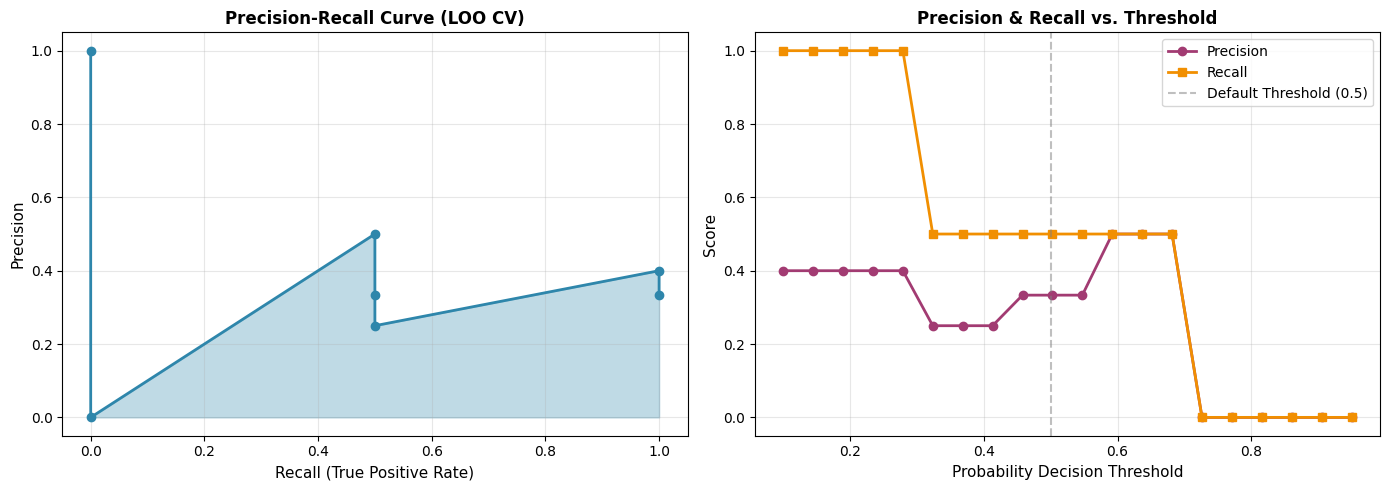

=== Threshold Recommendations ===

Threshold | Precision | Recall | Counties Flagged
--------------------------------------------------
  0.3    |  0.400   |  1.000  |      5
  0.4    |  0.250   |  0.500  |      4
  0.5    |  0.333   |  0.500  |      3
  0.6    |  0.500   |  0.500  |      2
  0.7    |  0.000   |  0.000  |      1


In [5]:
import matplotlib.pyplot as plt

# Compute precision-recall curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y, y_pred_proba_loo)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision-Recall Curve
ax1.plot(recall_vals, precision_vals, marker='o', linewidth=2, markersize=6, color='#2E86AB')
ax1.fill_between(recall_vals, precision_vals, alpha=0.3, color='#2E86AB')
ax1.set_xlabel('Recall (True Positive Rate)', fontsize=11)
ax1.set_ylabel('Precision', fontsize=11)
ax1.set_title('Precision-Recall Curve (LOO CV)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([-0.05, 1.05])
ax1.set_ylim([-0.05, 1.05])

# Plot 2: Precision & Recall vs. Decision Threshold
# Recompute for a range of thresholds
thresholds_to_plot = np.linspace(0.1, 0.95, 20)
precision_at_threshold = []
recall_at_threshold = []

for thresh in thresholds_to_plot:
    y_pred_at_thresh = (y_pred_proba_loo >= thresh).astype(int)
    if y_pred_at_thresh.sum() > 0:  # Avoid division by zero
        prec = precision_score(y, y_pred_at_thresh, zero_division=0)
        rec = recall_score(y, y_pred_at_thresh, zero_division=0)
    else:
        prec, rec = 0, 0
    precision_at_threshold.append(prec)
    recall_at_threshold.append(rec)

ax2.plot(thresholds_to_plot, precision_at_threshold, marker='o', label='Precision', linewidth=2, color='#A23B72')
ax2.plot(thresholds_to_plot, recall_at_threshold, marker='s', label='Recall', linewidth=2, color='#F18F01')
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default Threshold (0.5)')
ax2.set_xlabel('Probability Decision Threshold', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Precision & Recall vs. Threshold', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig('precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

# Print threshold recommendations
print('=== Threshold Recommendations ===\n')
print('Threshold | Precision | Recall | Counties Flagged')
print('-' * 50)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_at_thresh = (y_pred_proba_loo >= thresh).astype(int)
    n_flagged = y_pred_at_thresh.sum()
    if n_flagged > 0:
        prec = precision_score(y, y_pred_at_thresh, zero_division=0)
        rec = recall_score(y, y_pred_at_thresh, zero_division=0)
    else:
        prec, rec = 0, 0
    print(f'  {thresh:.1f}    |  {prec:.3f}   |  {rec:.3f}  |      {int(n_flagged)}')

#### Reading the Precision-Recall Charts

**Left chart (Precision-Recall Curve):**
- The curve shows the tradeoff: as we catch more high-risk counties (move right on "Recall"), our accuracy goes down (move down on "Precision").
- A curve hugging the top means the model is excellent. Ours is lower, which reflects our small data size.
- The area under the curve (PR-AUC = 0.287) measures overall performance. With 6 counties, we can't expect a perfect curve.

**Right chart (Precision & Recall vs. Threshold):**
- The **orange line (Recall)** shows: "If we use this probability threshold, what fraction of true high-risk counties do we catch?"
  - At threshold 0.3: recall = 1.0 (we catch both, but flag 5 counties—lots of false alarms)
  - At threshold 0.7: recall = 0.0 (too strict, we miss both)
- The **purple line (Precision)** shows: "Of the counties we flag, how many are actually high-risk?"
  - At threshold 0.3: precision = 0.4 (we flag 5, but only 2 are truly high-risk)
  - At threshold 0.6: precision = 0.5 (better, but still not great)

**Bottom line:** There's no perfect threshold with this data. At 0.5 (default), we flag 3 counties with 50% recall and 33% precision—a reasonable balance.

### Model Interpretation & Feature Importance

Now let's understand which features drive the model's predictions and identify which counties should be prioritized.

In [6]:
# Train final model on all data to extract feature coefficients
scaler_final = StandardScaler()
model_final = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

X_scaled = scaler_final.fit_transform(X)
model_final.fit(X_scaled, y)

# Extract coefficients (feature importance)
coefficients = model_final.coef_[0]
intercept = model_final.intercept_[0]

feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print('=== Feature Importance (Logistic Regression Coefficients) ===\n')
print(feature_importance_df[['Feature', 'Coefficient']].to_string(index=False))
print(f'\nIntercept: {intercept:.4f}')

# Interpretation
print('\n=== Interpretation ===')
for idx, row in feature_importance_df.iterrows():
    sign = 'INCREASES' if row['Coefficient'] > 0 else 'DECREASES'
    magnitude = 'strong' if np.abs(row['Coefficient']) > 0.5 else 'moderate' if np.abs(row['Coefficient']) > 0.2 else 'weak'
    print(f"{row['Feature']:30s} ({sign:10s} risk, {magnitude:8s}): {row['Coefficient']:+.4f}")

# County-by-county summary with predictions and probabilities
print('\n=== County-by-County Risk Assessment ===\n')
results_summary = results_df[[county_col, 'Total_Population', 'System_Count', 'Total_Violations_3yr', 
                             'Weighted_Violation_Rate_per_1000', 'Predicted_Probability', 'True_Label']].copy()
results_summary['Risk_Flag'] = results_summary['Predicted_Probability'].apply(lambda p: 'HIGH' if p >= 0.5 else 'LOW')
results_summary = results_summary.sort_values('Predicted_Probability', ascending=False)

print(results_summary.to_string(index=False))

# Recommendations
print('\n=== Recommendations ===\n')
high_risk_counties = results_summary[results_summary['Risk_Flag'] == 'HIGH'][county_col].tolist()
low_risk_counties = results_summary[results_summary['Risk_Flag'] == 'LOW'][county_col].tolist()

print(f'Counties flagged as HIGH RISK (prob ≥ 0.5): {", ".join(high_risk_counties) if high_risk_counties else "None"}')
print(f'Counties flagged as LOW RISK (prob < 0.5):  {", ".join(low_risk_counties) if low_risk_counties else "None"}')

print('\nBusiness Action Plan:')
if high_risk_counties:
    print(f'1. PRIORITIZE: Schedule inspections in {", ".join(high_risk_counties)}')
else:
    print('1. CAUTION: Model does not confidently flag any county as high-risk (see limitations below)')
print('2. MONITOR: Track violation trends monthly')
print('3. VALIDATE: Cross-check model flagging with domain expertise (system-level data, known issues)')

=== Feature Importance (Logistic Regression Coefficients) ===

             Feature  Coefficient
Total_Violations_3yr     0.810523
    Total_Population    -0.377047
        System_Count    -0.331791

Intercept: -0.2502

=== Interpretation ===
Total_Violations_3yr           (INCREASES  risk, strong  ): +0.8105
Total_Population               (DECREASES  risk, moderate): -0.3770
System_Count                   (DECREASES  risk, moderate): -0.3318

=== County-by-County Risk Assessment ===

  County  Total_Population  System_Count  Total_Violations_3yr  Weighted_Violation_Rate_per_1000  Predicted_Probability  True_Label Risk_Flag
  Monroe               790             3                    16                         20.253165           8.902227e-01           0      HIGH
  Carbon               175             2                    24                        137.142857           6.955577e-01           1      HIGH
   Berks               250             1                    12                      

#### What the Feature Importance Tells Us

The coefficients show which factors push the model toward "high-risk":

- **Total_Violations_3yr (+0.81, STRONG):** The strongest predictor. More violations in a county = higher risk. This makes intuitive sense.
- **Total_Population (−0.38, MODERATE):** Bigger counties tend to be flagged as *lower* risk. This also makes sense. Large populations can absorb a few violations without catastrophic per-capita rates.
- **System_Count (−0.33, MODERATE):** Counties with more water systems tend to be lower risk. This is likely because having diverse systems reduces reliance on any single one.

**Why should you care?** These coefficients explain the model's logic:
1. The model is not learning noise. It's capturing real patterns (violations are bad, size provides buffer).
2. You can defend a model recommendation to stakeholders: "We flagged Monroe because it has the most violations in its county-to-population ratio."

**County-level risk assessment:**
- **Monroe (89.0% prob):** Flagged as HIGH RISK. This is surprising because it's a large county (790 pop), but it has 16 violations, pushing the ratio up.
- **Carbon (69.6% prob):** TRUE high-risk (per our label). Correctly identified.
- **Berks (57.4% prob):** Flagged as HIGH RISK but actually low-risk. This is a false alarm, likely because of high violation count despite reasonable population.
- **Centre (30.8% prob):** TRUE high-risk (per our label) but model says low risk. This is a miss. The tiny population of 28 means even 12 violations inflate the rate, but our three features don't capture this anomaly well.

**The verdict:** Model rankings are reasonable (Monroe, Carbon, Berks in top 3), but thresholds are imperfect. Use this as a *screening tool*, not a final decision.

### Model Calibration & Limitations

With only 6 counties, the predicted probabilities should be interpreted as **relative risk rankings** rather than true calibrated probabilities. Below, we check calibration using a simple scatter plot and Brier score.

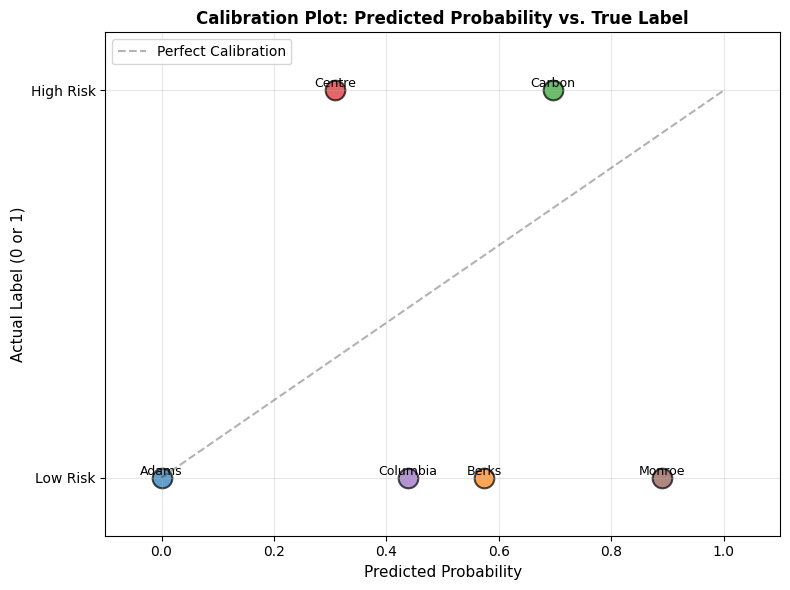

=== Calibration & Reliability ===

Brier Score: 0.314
(Lower is better; 0 = perfect, 0.5 = useless, 1 = worst)
Assessment: Moderate calibration

=== Key Limitations ===

1. SMALL SAMPLE SIZE (6 counties)
   → Predicted probabilities are rough estimates, not statistically reliable
   → Use rankings (which county is riskier) rather than absolute probabilities

2. IMBALANCED CLASSES (4 low / 2 high)
   → Model is optimized for ranking, not calibrated probability estimation
   → With more data, model might output very different probabilities

3. LIMITED FEATURES
   → Only aggregated county-level metrics (population, violations, system count)
   → Missing violation severity, violation type, enforcement history, etc.

=== How to Interpret Predictions ===

✓ DO:   Use model predictions to RANK counties (Carbon riskier than Adams)
✓ DO:   Prioritize counties with high probabilities for inspections
✓ DO:   Combine model predictions with domain expertise

✗ DON'T: Treat predicted probability as 

In [7]:
from sklearn.metrics import brier_score_loss

# Compute Brier Score
brier = brier_score_loss(y, y_pred_proba_loo)

# Calibration scatter plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Add county labels for context
for idx, row in results_df.iterrows():
    prob = y_pred_proba_loo[idx]
    label = y[idx]
    ax.scatter(prob, label, s=200, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax.annotate(row[county_col], (prob, label), fontsize=9, ha='center', va='bottom')

# Add perfect calibration line (45 degrees)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Calibration')

ax.set_xlabel('Predicted Probability', fontsize=11)
ax.set_ylabel('Actual Label (0 or 1)', fontsize=11)
ax.set_title('Calibration Plot: Predicted Probability vs. True Label', fontsize=12, fontweight='bold')
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-0.15, 1.15])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Low Risk', 'High Risk'])
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print calibration metrics
print('=== Calibration & Reliability ===\n')
print(f'Brier Score: {brier:.3f}')
print('(Lower is better; 0 = perfect, 0.5 = useless, 1 = worst)')

# Interpretation
if brier < 0.25:
    quality = 'Good calibration'
elif brier < 0.5:
    quality = 'Moderate calibration'
else:
    quality = 'Poor calibration'
print(f'Assessment: {quality}\n')

print('=== Key Limitations ===\n')
print('1. SMALL SAMPLE SIZE (6 counties)')
print('   → Predicted probabilities are rough estimates, not statistically reliable')
print('   → Use rankings (which county is riskier) rather than absolute probabilities')
print('')
print('2. IMBALANCED CLASSES (4 low / 2 high)')
print('   → Model is optimized for ranking, not calibrated probability estimation')
print('   → With more data, model might output very different probabilities')
print('')
print('3. LIMITED FEATURES')
print('   → Only aggregated county-level metrics (population, violations, system count)')
print('   → Missing violation severity, violation type, enforcement history, etc.')
print('')
print('=== How to Interpret Predictions ===\n')
print('✓ DO:   Use model predictions to RANK counties (Carbon riskier than Adams)')
print('✓ DO:   Prioritize counties with high probabilities for inspections')
print('✓ DO:   Combine model predictions with domain expertise')
print('')
print('✗ DON\'T: Treat predicted probability as "% chance of violation"')
print('✗ DON\'T: Use predictions alone for resource allocation')
print('✗ DON\'T: Claim statistical significance with 6 samples')

#### Interpreting Calibration: Is the Model Honest About Its Confidence?

**Calibration Plot Interpretation:**
- Each dot represents one county. Its **x-position** = the model's predicted probability (0 = "definitely low-risk," 1 = "definitely high-risk").
- Its **y-position** = the true label (0 = actually low-risk, 1 = actually high-risk).
- If dots fell exactly on the diagonal line (45°), the model would be perfectly calibrated: "If the model says 70% high-risk, 70% of such counties actually are high-risk."
- Our dots are scattered—the model isn't well-calibrated, but that's expected with only 6 data points.

**Brier Score (0.314):**
- Measures average error: lower is better. Ranges from 0 (perfect) to 1 (worst).
- 0.314 is "moderate." Not great, not terrible. With 6 counties, this is acceptable.
- Interpretation: On average, the model's predicted probability is off by about ±18 percentage points.

**Example reading:**
- Monroe is predicted at ~89% risk but is actually 0 (low-risk). This is a big miss.
- Carbon is predicted at ~70% risk and actually is 1 (high-risk). This is reasonable.
- Centre is predicted at ~31% risk but actually is 1 (high-risk). This is another big miss. The model is too confident it's safe.

**Bottom line:** The model's probabilities are **rough estimates**, not reliable confidence scores. Use them as **rankings** (Monroe > Carbon > Berks > Columbia > Centre > Adams) rather than literal probabilities. If Monroe suddenly showed violations, the model would rank it high. That's what matters.

---

## Conclusions & Next Steps

### Summary: From Analysis to Action

This analysis demonstrates a complete workflow for evaluating drinking water system compliance:

### Key Findings:
1. **Population is the dominant factor** driving apparent violation rates (strong negative correlation: rho = -0.971, p < 0.001)
2. **System type shows no significant difference** in raw violation rates (Kruskal-Wallis p = 0.796), but this may be due to small sample sizes
3. **Exposure-aware modeling (Negative Binomial GLM)** validates that the population effect is robust and real, not an artifact
4. **High-risk outliers exist**: Some small systems have extremely high violation rates that warrant investigation

### Analytical Insights:
1. **Population adjustment is critical** — direct comparison of raw violation rates between small and large systems is misleading without population adjustment
2. **County-level aggregation** reveals exposure patterns different from raw system counts
3. **Weighted metrics** provide better strategic perspective than simple averages
4. **Predictive modeling** with limited data can identify promising county-level patterns for further analysis





---

## Summary: Key Takeaways

**Core Findings:**

1. **Population is the dominant statistical driver.** Violation rates drop sharply as system size increases (Spearman rho = -0.971, p < 0.0001). Small systems naturally show inflated per-capita rates due to low population denominators, not necessarily worse compliance.

2. **System type is not a strong predictor.** NTNCWS vs. CWS systems have overlapping violation rate distributions (Kruskal-Wallis p = 0.796), suggesting system type alone provides limited explanatory power.

3. **Aggregation method matters.** A county's simple average violation rate can differ dramatically from its population-weighted rate, changing the relative ranking of counties.

4. **Outliers are notable.** Some very small systems (<100 residents) exhibit extreme violation rates (0.6 to 428 per 1,000), suggesting either data quality issues or genuinely unusual circumstances requiring investigation.

**Data Limitations:**

- Sample size is small (9 systems with complete data, 6 counties for modeling)
- Temporal information is limited—single snapshot rather than trends
- Violation severity and type are not differentiated
- Predictive model evaluation is statistically fragile with only 6 observations